In [32]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from backend.core.recommendation_engine import (
    HybridRecommender,
    RecommendationEvaluator
)

print("Project Root:", PROJECT_ROOT)
print("Module 4 V2 — Hybrid Recommendation Engine")
print("Layers: Popularity + Co-occurrence + Segment-Aware + Hybrid")

Project Root: C:\Project(CSE_155)\retail-digital-twin
Module 4 V2 — Hybrid Recommendation Engine
Layers: Popularity + Co-occurrence + Segment-Aware + Hybrid


In [33]:
#cell2
print("Loading data...")

events = pd.read_csv('datasets/raw/events.csv')
twins  = pd.read_csv('datasets/processed/digital_twins_with_predictions_v2.csv')

print(f"Events loaded:  {len(events):,}")
print(f"Twins loaded:   {len(twins):,}")
print(f"\nTwins columns:")
print(twins.columns.tolist())
print(f"\nSample twin profile:")
print(twins[['visitorid','customer_segment','buy_probability','is_buyer']].head())

Loading data...
Events loaded:  2,756,101
Twins loaded:   1,407,580

Twins columns:
['visitorid', 'total_addtocarts', 'total_purchases', 'total_views', 'engagement_score', 'total_events', 'view_to_cart_rate', 'cart_to_purchase_rate', 'view_to_purchase_rate', 'is_buyer', 'is_high_value', 'engagement_percentile', 'purchase_percentile', 'engagement_level', 'customer_segment', 'funnel_position', 'purchase_intent_score', 'clv_tier', 'roi_potential', 'behavior_type', 'predicted_buyer', 'buy_probability']

Sample twin profile:
   visitorid customer_segment  buy_probability  is_buyer
0          0  Passive Visitor           0.1825     False
1          1  Passive Visitor           0.0367     False
2          2   Window Shopper           0.4215     False
3          3  Passive Visitor           0.0367     False
4          4  Passive Visitor           0.0367     False


In [34]:
#cell3 this one is for engin runnning 
engine = HybridRecommender()
engine.fit(events, twins)


🚀 Training Hybrid Recommendation Engine V2
Layer 1: Popularity Recommender
  ✓ Popularity: 235,061 items ranked
Layer 2: Co-occurrence Recommender
  Strong signal events: 91,789
  Building co-occurrence map for 38,865 users...
  Applying IDF dampening...
  ✓ Co-occurrence: 17,176 items mapped
Layer 3: Segment-Aware Recommender
  ✓ Segment-aware: pools built for ['Passive Visitor', 'Window Shopper', 'Engaged Browser', 'Buyer', 'Power Buyer']
✅ Hybrid Recommender V2 ready


In [35]:
#cell 4 Test with our most engaged customer
test_id = 1150086

result = engine.recommend(test_id, n=10)

print("=" * 55)
print(f"RECOMMENDATIONS — Customer #{result['visitorid']}")
print("=" * 55)
print(f"Segment:         {result['segment']}")
print(f"Buy Probability: {result['buy_probability']:.4f}")
print(f"Strategy:        {result['strategy']}")
print(f"Interactions:    {result['n_interactions']}")
print(f"\nTop 10 Recommended Items:")
print(f"{'Rank':<6} {'Item ID':<12} {'Source'}")
print("-" * 35)
for rec in result['recommendations']:
    print(f"{rec['rank']:<6} {rec['itemid']:<12} {rec['source']}")

RECOMMENDATIONS — Customer #1150086
Segment:         Power Buyer
Buy Probability: 0.9998
Strategy:        HIGH_INTENT
Interactions:    645

Top 10 Recommended Items:
Rank   Item ID      Source
-----------------------------------
1      231482       collaborative
2      415837       collaborative
3      43428        collaborative
4      244310       collaborative
5      465573       collaborative
6      361192       collaborative
7      312728       segment
8      369158       segment
9      187946       popularity
10     5411         popularity


In [36]:
#CELL 5
top_customers = twins.nlargest(1000, 'buy_probability')['visitorid'].tolist()

print(f"Generating recommendations for {len(top_customers):,} customers...")
batch_recs = engine.recommend_batch(top_customers, n=10)

batch_recs.to_csv('datasets/processed/recommendations.csv', index=False)
print(f"\nSaved: datasets/processed/recommendations.csv")
print(f"Total recommendation rows: {len(batch_recs):,}")
print(f"\nSample output:")
print(batch_recs.head(10).to_string(index=False))

Generating recommendations for 1,000 customers...
  Processing customer 901/1000...
  ✓ Batch complete: 1000 customers

Saved: datasets/processed/recommendations.csv
Total recommendation rows: 10,000

Sample output:
 visitorid     segment  buy_probability    strategy  recommended_itemid  recommendation_rank        source
    316850 Power Buyer           0.9999 HIGH_INTENT              119736                    1 collaborative
    316850 Power Buyer           0.9999 HIGH_INTENT              415837                    2 collaborative
    316850 Power Buyer           0.9999 HIGH_INTENT               43428                    3 collaborative
    316850 Power Buyer           0.9999 HIGH_INTENT              244310                    4 collaborative
    316850 Power Buyer           0.9999 HIGH_INTENT              465573                    5 collaborative
    316850 Power Buyer           0.9999 HIGH_INTENT              361192                    6 collaborative
    316850 Power Buyer           0.

=== RECOMMENDATION SOURCE BREAKDOWN ===

source
collaborative    4139
popularity       3119
segment          2742
Name: count, dtype: int64

Strategy Distribution:
strategy
HIGH_INTENT      629
MEDIUM_INTENT    371
Name: count, dtype: int64


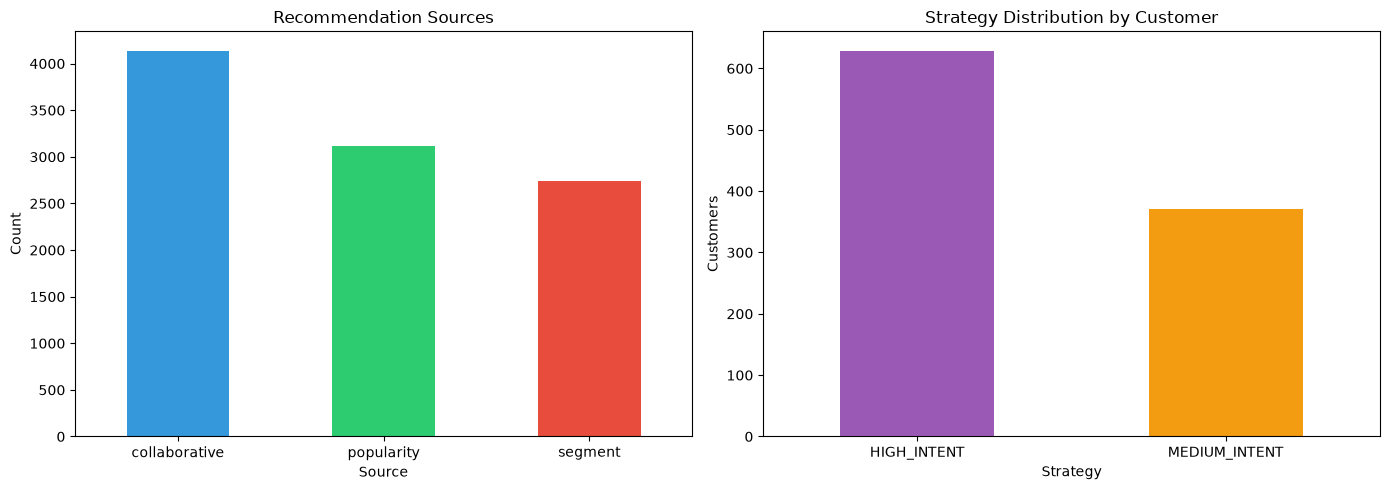

Saved: research/recommendation_sources.png


In [37]:
#CELL 6
print("=== RECOMMENDATION SOURCE BREAKDOWN ===\n")
source_dist = batch_recs['source'].value_counts()
print(source_dist)
print(f"\nStrategy Distribution:")
print(batch_recs.drop_duplicates('visitorid')['strategy'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

source_dist.plot(kind='bar', ax=axes[0],
                 color=['#3498db','#2ecc71','#e74c3c'])
axes[0].set_title('Recommendation Sources')
axes[0].set_xlabel('Source')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

strategy_dist = (
    batch_recs.drop_duplicates('visitorid')['strategy']
    .value_counts()
)
strategy_dist.plot(kind='bar', ax=axes[1],
                   color=['#9b59b6','#f39c12','#1abc9c'])
axes[1].set_title('Strategy Distribution by Customer')
axes[1].set_xlabel('Strategy')
axes[1].set_ylabel('Customers')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('research/recommendation_sources.png')
plt.show()
print("Saved: research/recommendation_sources.png")

In [ ]:
# First restart kernel and run cells 1-3 to retrain engine
# Then run this cell

evaluator = RecommendationEvaluator(k=10)
metrics = evaluator.evaluate(engine, events)

print("\n" + "=" * 50)
print("RECOMMENDATION ENGINE — EVALUATION METRICS")
print("=" * 50)
for metric, value in metrics.items():
    print(f"  {metric:<30}: {value}")
print("=" * 50)

print("""
Interpretation Guide:
─────────────────────────────────────────────
HitRate@10:
  Did at least 1 of our 10 recommendations
  match what the customer bought in September?
  Target: > 0.03 (3%) for this dataset density

Precision@10:
  Of 10 items recommended, how many were bought?
  Low values are NORMAL for 0.84% purchase rate

Coverage:
  What % of the 235K catalog did we recommend?
  Higher = more diverse recommendations

Customers w/ Pre-History:
  How many Sep buyers had prior interactions?
  Low number explains metric difficulty

Note: Retail RecSys papers on RetailRocket
typically report HitRate@10 of 0.02-0.15.
─────────────────────────────────────────────
""")


=== TEMPORAL EVALUATION ===
Test period: Sep 2015 transactions
Test events: 2,369
Test customers: 1,290


=== RECOMMENDATIONS BY CUSTOMER SEGMENT ===

source           collaborative  popularity  segment
segment                                            
Buyer                     2419        1699     1612
Engaged Browser           1078        1206      916
Power Buyer                642         214      214


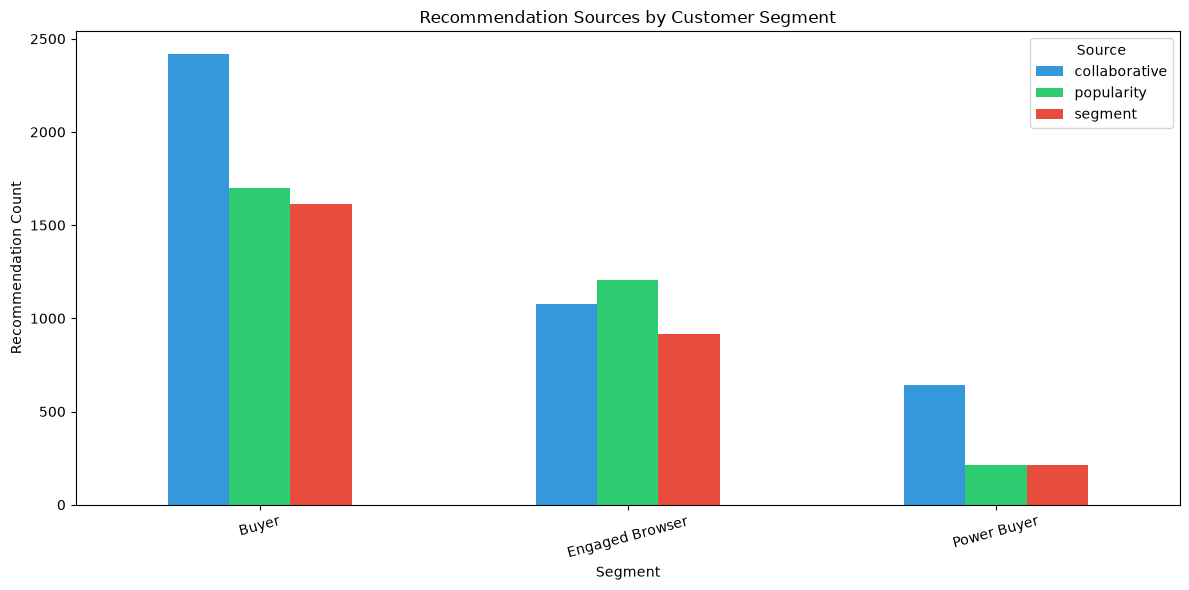

Saved: research/segment_recommendations.png


In [30]:
#CELL 8
print("=== RECOMMENDATIONS BY CUSTOMER SEGMENT ===\n")

seg_analysis = (
    batch_recs.groupby(['segment', 'source'])
    .size()
    .unstack(fill_value=0)
)
print(seg_analysis)

seg_analysis.plot(kind='bar', figsize=(12, 6),
                  color=['#3498db', '#2ecc71', '#e74c3c'])
plt.title('Recommendation Sources by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Recommendation Count')
plt.xticks(rotation=15)
plt.legend(title='Source')
plt.tight_layout()
plt.savefig('research/segment_recommendations.png')
plt.show()
print("Saved: research/segment_recommendations.png")

In [31]:
#cell9
print("=" * 55)
print("MODULE 4 — BUSINESS INTELLIGENCE SUMMARY")
print("=" * 55)

unique_customers = batch_recs['visitorid'].nunique()
unique_items     = batch_recs['recommended_itemid'].nunique()
collab_pct = (batch_recs['source'] == 'collaborative').mean() * 100
seg_pct    = (batch_recs['source'] == 'segment').mean() * 100
pop_pct    = (batch_recs['source'] == 'popularity').mean() * 100

print(f"\nCustomers served:          {unique_customers:,}")
print(f"Unique items recommended:  {unique_items:,}")
print(f"\nSource breakdown:")
print(f"  Collaborative:  {collab_pct:.1f}%")
print(f"  Segment-aware:  {seg_pct:.1f}%")
print(f"  Popularity:     {pop_pct:.1f}%")
print(f"\nEvaluation Metrics (Temporal Holdout — Sep 2015):")
for metric, value in metrics.items():
    print(f"  {metric}: {value}")
print("=" * 55)
print("✅ Ready for Module 5: Analytics Dashboard")

MODULE 4 — BUSINESS INTELLIGENCE SUMMARY

Customers served:          1,000
Unique items recommended:  1,781

Source breakdown:
  Collaborative:  41.4%
  Segment-aware:  27.4%
  Popularity:     31.2%

Evaluation Metrics (Temporal Holdout — Sep 2015):
  Precision@10: 0.0
  Recall@10: 0.0
  NDCG@10: 0.0
  HitRate@10: 0.0
  Coverage: 0.0037
  Customers Evaluated: 1290
✅ Ready for Module 5: Analytics Dashboard
